### Preprocessing





In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
from tqdm import tqdm

sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data_1.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data_1.h5ad")


In [ ]:
print(sc_ad)

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'COVET_genes', 'hvg'
    obsm: 'COVET', 'COVET_SQRT', 'UMAP_exp', 'cell_type_niche', 'envi_latent'
    layers: 'log'


In [ ]:
print(st_ad)

AnnData object with n_obs × n_vars = 276556 × 254
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label', 'Layer_Depth', 'Depth'
    var: 'n_iso', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'


In [16]:
sc_2=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
print(sc_2)

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'COVET_genes', 'hvg'
    obsm: 'COVET', 'COVET_SQRT', 'UMAP_exp', 'cell_type_niche', 'envi_latent'
    layers: 'log'


In [9]:
sc_1=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data_1.h5ad")
st_1=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")


In [10]:
sc_1

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'COVET_genes', 'hvg'
    obsm: 'COVET', 'COVET_SQRT', 'UMAP_exp', 'cell_type_niche', 'envi_latent'
    layers: 'log'

In [3]:
envi_latent_st = sc_ad.obsm['envi_latent']
envi_latent_sc = st_ad.obsm['envi_latent']
print(envi_latent_st.shape)
print(envi_latent_sc.shape)

combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)

(7416, 512)
(18516, 512)
(25932, 512)


In [11]:
st_1

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'
    layers: 'X', 'log1p', 'norm'

In [4]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)
Reduced shape: (25932, 50)
Shape after flattening:  (25932, 4096)
Reduced shape: (25932, 50)
(25932, 100)


### Creating Anndata for the combined matrix

In [1]:
adata=ad.AnnData(X=combined_matrix)

# save this adata in h5ad format in a file name e_pca_combined
adata.write_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/e_pca_combined.h5ad")
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], frameon=False)


NameError: name 'ad' is not defined

### Calculating KNN indices for both COVET and ENVI

In [8]:
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

def compute_knn_indices(data, n_neighbors):
    """
    Computes k-nearest neighbors for each point in the dataset.

    :param data: (array) Data matrix of shape (n_samples, n_features)
    :param n_neighbors: (int) Number of nearest neighbors
    :return: (tuple) knn_indices (n_samples, k), knn_distances (n_samples, k), fitted NearestNeighbors object
    """
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)
    knn_distances = np.zeros((n_samples, n_neighbors), dtype=float)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        distances, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        knn_distances[i] = distances[0]
        
    return knn_indices, knn_distances, nbrs

In [9]:
knn_indices_covet, knn_distances_covet, _ = compute_knn_indices(covet_pca, n_neighbors=10)
knn_indices_envi, knn_distances_envi, _= compute_knn_indices(envi_pca, n_neighbors=10)

Computing kNN: 100%|█████████████████████| 25932/25932 [01:15<00:00, 343.15it/s]


### Computing snn matrix for envi using MAX

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix(knn_indices, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using ranking-based weighting.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Precompute neighbor sets and ranking dictionaries
    neighbor_sets = [set(knn_indices[i]) for i in range(n_samples)]
    rankings = [{knn_indices[i][j]: j + 1 for j in range(len(knn_indices[i]))} for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = neighbor_sets[i]

        for j in range(i + 1, n_samples):
            neighbors_j = neighbor_sets[j]
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                max_weight = max(
                    n_neighbors - 0.5 * (rankings[i][v] + rankings[j][v])
                    for v in shared_neighbors
                )
                # max_weight = max(0.5 * (rankings[i][v] + rankings[j][v])
                #     for v in shared_neighbors)
                snn_matrix[i, j] = max_weight
                snn_matrix[j, i] = max_weight  # Symmetric assignment

    return csr_matrix(snn_matrix)


In [11]:
snn_envi=compute_snn_matrix(knn_indices_envi)

Computing SNN Matrix: 100%|██████████████| 25932/25932 [01:23<00:00, 310.85it/s]


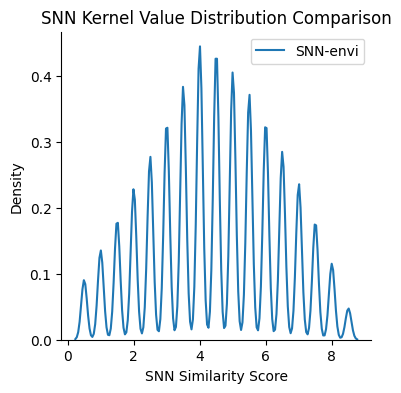

In [88]:
sns.kdeplot(snn_envi.data, label="SNN-envi")
plt.legend()
plt.title("SNN Kernel Value Distribution Comparison")
plt.xlabel("SNN Similarity Score")
plt.ylabel("Density")
plt.show()

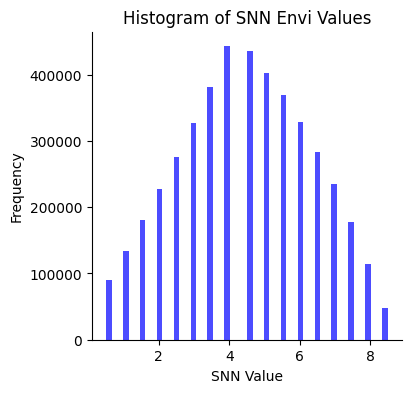

In [89]:
snn_envi_values = snn_envi.data
plt.hist(snn_envi_values, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN Envi Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

### SNN for ENVI using Average

In [25]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix_avg(knn_indices, knn_distances, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using average distances
    of shared neighbors instead of rankings.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param knn_distances: (array) Distances to k-nearest neighbors (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Build neighbor distance dictionaries
    distance_dicts = [{knn_indices[i][j]: knn_distances[i][j] for j in range(knn_indices.shape[1])}
                      for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = set(knn_indices[i])

        for j in range(i + 1, n_samples):
            neighbors_j = set(knn_indices[j])
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                avg_distances = [
                    0.5 * (distance_dicts[i][v] + distance_dicts[j][v])
                    for v in shared_neighbors
                ]
                mean_avg_distance = np.mean(avg_distances)

                
                similarity = 1.0 / (1.0 + mean_avg_distance)  

                snn_matrix[i, j] = similarity
                snn_matrix[j, i] = similarity  

    return csr_matrix(snn_matrix)


In [26]:
snn_envi_avg=compute_snn_matrix_avg(knn_indices_envi, knn_distances_envi)

Computing SNN Matrix: 100%|███████████████| 25932/25932 [05:58<00:00, 72.25it/s]


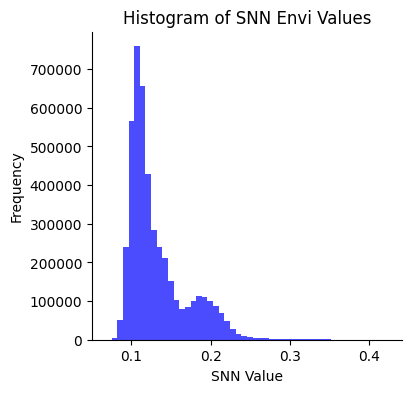

In [90]:
plt.hist(snn_envi_avg.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN Envi Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

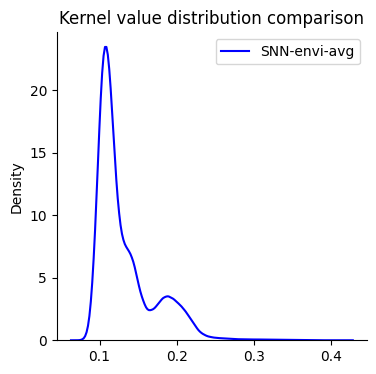

In [91]:
sns.kdeplot(snn_envi_avg.data, label="SNN-envi-avg", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

### Calculating COVET through max for analysis

In [29]:
snn_covet=compute_snn_matrix(knn_indices_covet, knn_distances_covet)

Computing SNN Matrix: 100%|███████████████| 25932/25932 [05:50<00:00, 74.07it/s]


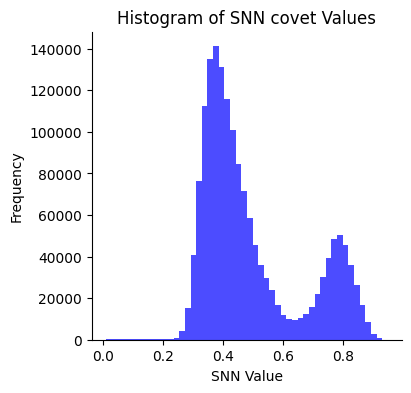

In [39]:
snn_covet_values = snn_covet.data

# Plot histogram
plt.hist(snn_covet_values, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN covet Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

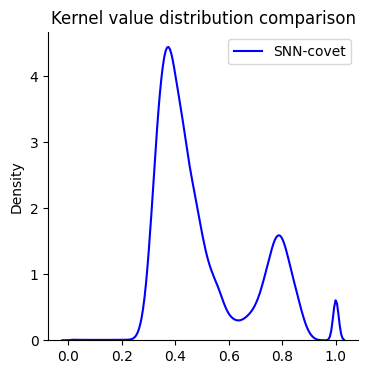

In [63]:
sns.kdeplot(snn_covet.data, label="SNN-covet", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

### Calculating COVET through average

In [96]:
snn_covet_avg=compute_snn_matrix_avg(knn_indices_covet, knn_distances_covet)

Computing SNN Matrix: 100%|███████████████| 25932/25932 [05:46<00:00, 74.87it/s]


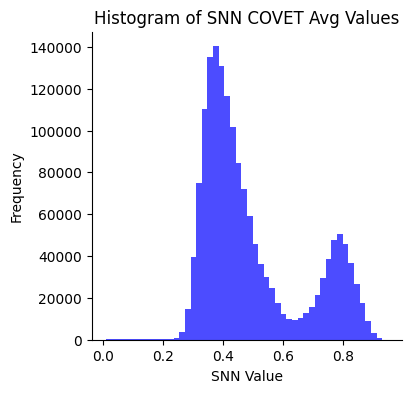

In [97]:
plt.hist(snn_covet_avg.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN COVET Avg Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

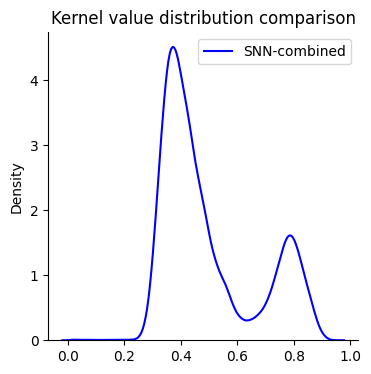

In [98]:
sns.kdeplot(snn_covet_avg.data, label="SNN-combined", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

### Combining SNN Combined using snn_avg and covet max

In [93]:
snn_combined = (snn_envi_avg+ snn_covet) / 2
print(snn_combined)

  (0, 0)	0.5
  (0, 18)	0.09918241947889328
  (0, 60)	0.09494557231664658
  (0, 73)	0.2087499350309372
  (0, 194)	0.20777584612369537
  (0, 241)	0.22563287615776062
  (0, 400)	0.09666286408901215
  (0, 436)	0.10004815459251404
  (0, 511)	0.09214254468679428
  (0, 521)	0.11317865550518036
  (0, 543)	0.09251078218221664
  (0, 557)	0.1027020737528801
  (0, 583)	0.0962505117058754
  (0, 585)	0.21624504029750824
  (0, 597)	0.10459218174219131
  (0, 631)	0.09955260902643204
  (0, 671)	0.10265935212373734
  (0, 753)	0.09893453866243362
  (0, 805)	0.09770370274782181
  (0, 854)	0.09205456078052521
  (0, 1084)	0.21112392842769623
  (0, 1097)	0.11777538061141968
  (0, 1139)	0.09900526702404022
  (0, 1149)	0.23915612697601318
  (0, 1182)	0.09924088418483734
  :	:
  (25931, 24753)	0.056756287813186646
  (25931, 24786)	0.05442831665277481
  (25931, 24837)	0.05812457576394081
  (25931, 24897)	0.37090736627578735
  (25931, 24965)	0.052831511944532394
  (25931, 25014)	0.04859777167439461
  (25931, 2503

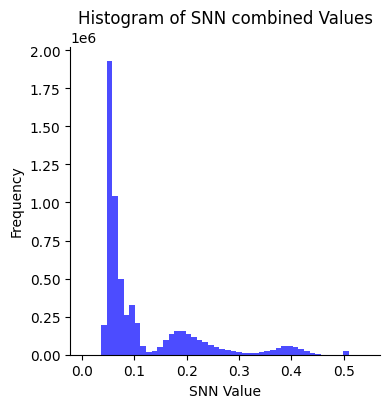

In [94]:
plt.hist(snn_combined.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN combined Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

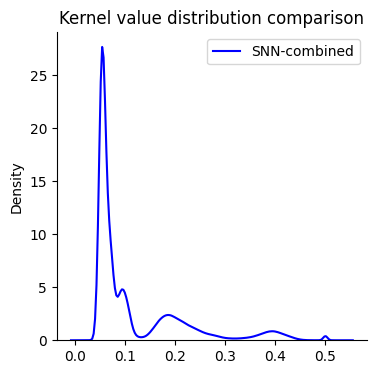

In [95]:
sns.kdeplot(snn_combined.data, label="SNN-combined", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

## Combining both avg based

In [101]:
snn_combined_avg = (snn_envi_avg+ snn_covet_avg) / 2
print(snn_combined)

  (0, 18)	0.09918241947889328
  (0, 60)	0.09494557231664658
  (0, 73)	0.20871233940124512
  (0, 194)	0.20868727564811707
  (0, 241)	0.22649241983890533
  (0, 400)	0.09666286408901215
  (0, 436)	0.10004815459251404
  (0, 511)	0.09214254468679428
  (0, 521)	0.11317865550518036
  (0, 543)	0.09251078218221664
  (0, 557)	0.1027020737528801
  (0, 583)	0.0962505117058754
  (0, 585)	0.2162594348192215
  (0, 597)	0.10459218174219131
  (0, 631)	0.09955260902643204
  (0, 671)	0.10265935212373734
  (0, 753)	0.09893453866243362
  (0, 805)	0.09770370274782181
  (0, 854)	0.09205456078052521
  (0, 1084)	0.20927193760871887
  (0, 1097)	0.11777538061141968
  (0, 1139)	0.09900526702404022
  (0, 1149)	0.2380003184080124
  (0, 1182)	0.09924088418483734
  (0, 1425)	0.0919615626335144
  :	:
  (25931, 24591)	0.33845391869544983
  (25931, 24753)	0.056756287813186646
  (25931, 24786)	0.05442831665277481
  (25931, 24837)	0.05812457576394081
  (25931, 24897)	0.37132588028907776
  (25931, 24965)	0.0528315119445323

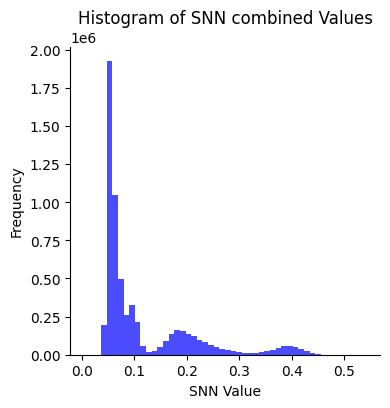

In [102]:
plt.hist(snn_combined_avg.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN combined Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

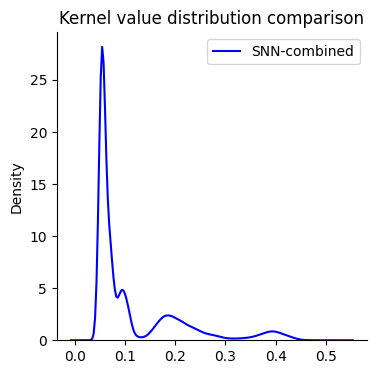

In [103]:
sns.kdeplot(snn_combined_avg.data, label="SNN-combined", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

### Adding the snn combined to obsp of the adata so as to use it in the package directly

In [ ]:
adata.obsp["snn_graph"] = snn_combined

In [43]:
raw_ad=sc.AnnData(adata.X)
raw_ad.obs_names, raw_ad.var_names=adata.obs_names, adata.var_names
adata.raw=raw_ad


## Computing SNN based RBF Kernel
### Instead of Euclidean distance, we use SNN similarity scores.

In [32]:
# optimization
# for parallelizing stuff
def snn_rbf_row(i, snn_dense_row):
    return np.exp(-1 / (snn_dense_row + 1e-8))

from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
NUM_CORES = cpu_count()

def snn_rbf_kernel(adata,  graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) based RBF kernel.
        Instead of Euclidean distance, we use SNN similarity scores.
        
        :return: (sparse matrix) SNN-RBF kernel matrix
        """

        snn_matrix= adata.obsp["snn_graph"]
        
        
        # Ensure symmetry in SNN matrix (if not already)
        sym_snn_matrix = (snn_matrix + snn_matrix.T) / 2
        n, d=adata.obsm["X_pca"].shape
        # Convert to dense format (if needed for iteration)
        snn_dense = sym_snn_matrix.toarray()
        num_cores = cpu_count()
        # Compute kernel using SNN weights instead of Euclidean distances
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
                    similarity_matrix_rows = parallel(
                        delayed(snn_rbf_row)(i, snn_dense[i]) for i in tqdm(range(n))
                        )
        
        
        similarity_matrix = lil_matrix((n,n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]
        
        # Ensure diagonal elements are exactly 1
        similarity_matrix.setdiag(1.0)
        
        
        M = similarity_matrix.tocsr()
        return M


In [33]:
similarity_matrix= snn_rbf_kernel(adata, snn_combined_avg)

  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

## Computing Similarity matrix using the original seacells rbf function 

In [11]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
def rbf_for_row(G, data, median_distances, i):
    """Helper function for computing radial basis function kernel for each row of the data matrix.

    :param G: (array) KNN graph representing nearest neighbour connections between cells
    :param data: (array) data matrix between which euclidean distances are computed for RBF
    :param median_distances: (array) radius for RBF - the median distance between cell and k nearest-neighbours
    :param i: (int) data row index for which RBF is calculated
    :return: sparse matrix containing computed RBF for row
    """
    # convert row to binary numpy array
    row_as_array = G[i, :].toarray().ravel()

    # compute distances ||x - y||^2 in PC/original X space
    numerator = np.sum(np.square(data[i, :] - data), axis=1, keepdims=False)

    # compute radii - median distance is distance to kth nearest neighbor
    denominator = median_distances[i] * median_distances

    # exp
    full_row = np.exp(-numerator / denominator)

    # masked row - to contain only indices captured by G matrix
    masked_row = np.multiply(full_row, row_as_array)

    return lil_matrix(masked_row)

def kth_neighbor_distance(distances, k, i):
    """Returns distance to kth nearest neighbor.

    Distances: sparse CSR matrix
    k: kth nearest neighbor
    i: index of row
    .
    """
    # convert row to 1D array
    row_as_array = distances[i, :].toarray().ravel()

    # number of nonzero elements
    num_nonzero = np.sum(row_as_array > 0)

    # argsort
    kth_neighbor_idx = np.argsort(np.argsort(-row_as_array)) == num_nonzero - k
    return np.linalg.norm(row_as_array[kth_neighbor_idx])


def rbf(adata, k: int = 15, graph_construction="union"):
        """Initialize adaptive bandwith RBF kernel (as described in C-isomap).

        :param k: (int) number of nearest neighbors for RBF kernel
        :return: (sparse matrix) constructed RBF kernel
        """
        import scanpy as sc

        knn_graph_distances = adata.obsp["distances"]
        n, d=adata.obsm["X_pca"].shape
        # Binarize distances to get connectivity
        knn_graph = knn_graph_distances.copy()
        knn_graph[knn_graph != 0] = 1
        # Include self as neighbour
        knn_graph.setdiag(1)

        knn_graph = knn_graph
        
            # compute median distance for each point amongst k-nearest neighbors
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            median = k // 2
            median_distances = parallel(
                delayed(kth_neighbor_distance)(knn_graph_distances, median, i)
                for i in tqdm(range(n))
            )

        # convert to numpy array
        median_distances = np.array(median_distances)

       
        print(
            f"Parameter graph_construction = {graph_construction} being used to build KNN graph..."
        )
        if graph_construction == "union":
            sym_graph = (knn_graph + knn_graph.T > 0).astype(float)
        elif graph_construction in ["intersect", "intersection"]:
            knn_graph = (knn_graph > 0).astype(float)
            sym_graph = knn_graph.multiply(knn_graph.T)
        else:
            raise ValueError(
                f"Parameter graph_construction = {graph_construction} is not valid. \
             Please select `union` or `intersection`"
            )
        
        sym_graph= sym_graph
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            similarity_matrix_rows = parallel(
                delayed(rbf_for_row)(
                    sym_graph, adata.obsm["X_pca"], median_distances, i
                )
                for i in tqdm(range(n))
            )

      
        similarity_matrix = lil_matrix((n, n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]

        
        M = (similarity_matrix).tocsr()
        return M


In [12]:
similarity_matrix_rbf=rbf(adata)

  0%|          | 0/25932 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

In [13]:
print(similarity_matrix_rbf)

  (0, 0)	1.0
  (0, 60)	0.47115407012876914
  (0, 1097)	0.34726649686778577
  (0, 1736)	0.28858808687062987
  (0, 2184)	0.3678794514975475
  (0, 3087)	0.4393550366467563
  (0, 3359)	0.40809109115057957
  (0, 3398)	0.3558465843292287
  (0, 4346)	0.36998523517579407
  (0, 4907)	0.31592451092936225
  (0, 6228)	0.3171013486158785
  (0, 6303)	0.4698002481671702
  (0, 6692)	0.2953835047677023
  (0, 6766)	0.3409889463470584
  (0, 6935)	0.17551031243482088
  (0, 7115)	0.35963722909485496
  (0, 7150)	0.34298093233054355
  (0, 20631)	0.20133142684971894
  (1, 1)	1.0
  (1, 87)	0.3986990968221084
  (1, 146)	0.3307233901589586
  (1, 346)	0.37228221358799324
  (1, 553)	0.3766574127461536
  (1, 2101)	0.38275884023173307
  (1, 3334)	0.3512445559960168
  :	:
  (25930, 13768)	0.32070354919912364
  (25930, 14278)	0.2888294356408416
  (25930, 14294)	0.31590780792696366
  (25930, 15838)	0.36136392285900537
  (25930, 18605)	0.332673977759885
  (25930, 21761)	0.32718676331744734
  (25930, 25930)	1.0
  (25931,

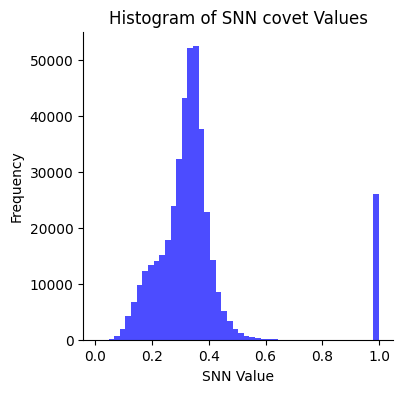

In [105]:
plt.hist(similarity_matrix_rbf.data, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of SNN covet Values")
plt.xlabel("SNN Value")
plt.ylabel("Frequency")
plt.show()

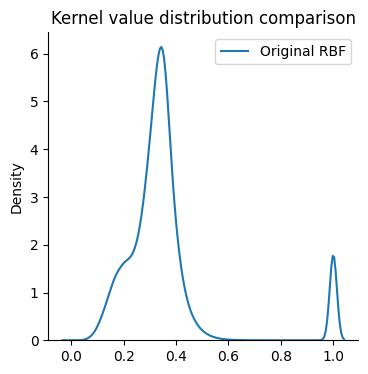

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()


### my custom rbf kernel seems too discretized as compared to the smooth gaussian kernel, which is something that seacells expects. how to fix that

## Checking if smoothening similarity matrix using the normalized data makes any difference

In [37]:
# optimization
# for parallelizing stuff
def snn_rbf_row(i, snn_dense_row, sigma=0.3):
    data_array = np.asarray(snn_dense_row.data)  # Convert memoryview to array
    return np.exp(-((1.0 - data_array) ** 2) / (2 * sigma ** 2))

from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
NUM_CORES = cpu_count()

def snn_rbf_kernel(snn, graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) based RBF kernel.
        Instead of Euclidean distance, we use SNN similarity scores.
        
        :return: (sparse matrix) SNN-RBF kernel matrix
        """

        snn_matrix= snn
        
        
        # Ensure symmetry in SNN matrix (if not already)
        sym_snn_matrix = (snn_matrix + snn_matrix.T) / 2
        n, d=adata.obsm["X_pca"].shape
        # Convert to dense format (if needed for iteration)
        snn_dense = sym_snn_matrix.toarray()
        num_cores = cpu_count()
        # Compute kernel using SNN weights instead of Euclidean distances
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
                    similarity_matrix_rows = parallel(
                        delayed(snn_rbf_row)(i, snn_dense[i]) for i in tqdm(range(n))
                        )
        
        
        similarity_matrix = lil_matrix((n,n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]
        
        # Ensure diagonal elements are exactly 1
        similarity_matrix.setdiag(1.0)
        
        
        M = similarity_matrix.tocsr()
        return M


In [ ]:
similarity_matrix_post_normalization=snn_rbf_kernel(snn=snn_combined)

  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

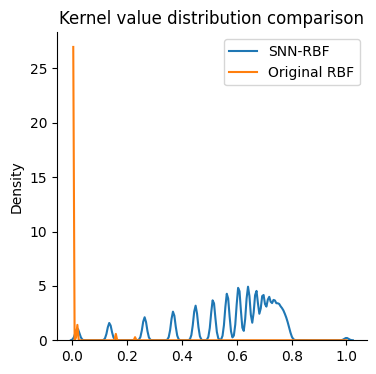

In [21]:
sns.kdeplot(similarity_matrix.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_post_normalization.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

## Trying SNN Similarity Kernel
### Instead of converting SNN to distances and using RBF, we use the raw SNN similarity,normalized between 0 and 1 to act as a kernel.

In [18]:
def snn_kernel(snn, graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) similarity kernel.
        Instead of converting SNN to distances and using RBF, we use the raw SNN similarity,
        normalized between 0 and 1 to act as a kernel.
        
        :return: (sparse matrix) normalized SNN similarity matrix
        """
        print("Welcome to normalized SNN kernel!")
        normalized_snn= snn

        print("Symmetrizing the SNN graph...")


        # Force diagonal to 1 (each cell is fully similar to itself)
        normalized_snn.setdiag(1.0)

        print("Converting to CSR format...")

        M = normalized_snn.tocsr()
        return M


In [19]:
similarity_matrix_normal= snn_kernel(normalized_snn)

Welcome to normalized SNN kernel!
Symmetrizing the SNN graph...
Converting to CSR format...


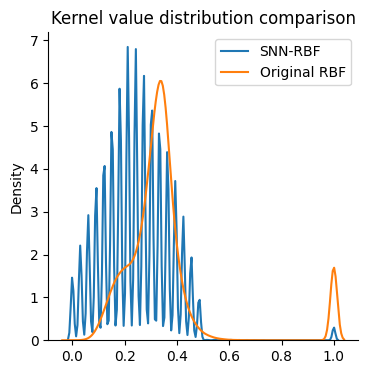

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(similarity_matrix_normal.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

## Applying Gaussian Blur row wise to similarity Matrix

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def smooth_similarity_matrix(sim_matrix, sigma=1.0):
    """
    Applies a Gaussian blur row-wise to a similarity matrix.

    Parameters:
    - sim_matrix (np.ndarray): Dense similarity matrix (n x n).
    - sigma (float): Standard deviation for Gaussian kernel.

    Returns:
    - np.ndarray: Smoothed similarity matrix.
    """
    # Apply row-wise Gaussian smoothing
    smoothed = np.zeros_like(sim_matrix)
    for i in range(sim_matrix.shape[0]):
        smoothed[i] = gaussian_filter(sim_matrix[i], sigma=sigma)
    return smoothed

from scipy.sparse import csr_matrix

def smooth_sparse_similarity(sparse_matrix, sigma=1.0):
    dense = sparse_matrix.toarray()
    smoothed = smooth_similarity_matrix(dense, sigma=sigma)
    return csr_matrix(smoothed)  # or leave dense if SEACells can handle it


In [21]:
similarity_matrix_normal.shape

(25932, 25932)

In [22]:

def smooth_similarity_matrix(sim_matrix, sigma=1.0):
    sim_matrix = np.asarray(sim_matrix)
    if sim_matrix.ndim != 2:
        raise ValueError("Input similarity matrix must be 2D.")
    return gaussian_filter(sim_matrix, sigma=sigma)
smoothed_kernel_sparse = smooth_sparse_similarity(similarity_matrix_normal, sigma=1.5)


In [23]:
sns.kdeplot(smoothed_kernel_sparse.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

: 

## Applying SEACells

In [2]:
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [ ]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              convergence_epsilon=1e-5
                              )

### Using the function snn_kernel() in build_graphs.py of SEACells to calculate the kernel matrix

In [47]:
model.construct_kernel_matrix_updated()

using your code
Using the updated snn_kernel to calculate this 
Welcome to normalized SNN kernel!
Converting to CSR format...


In [48]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 97 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 13/13 [00:00<00:00, 17.92it/s]

Selecting 3 cells from greedy initialization.


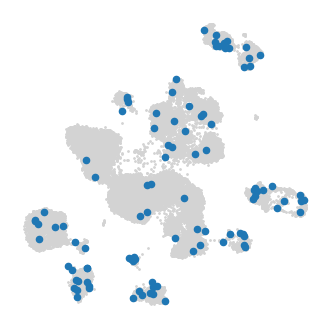

In [49]:
SEACells.plot.plot_initialization(adata, model)

In [50]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00665
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.


KeyboardInterrupt: 

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


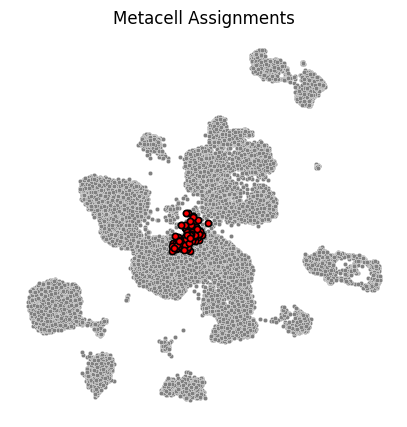

In [51]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


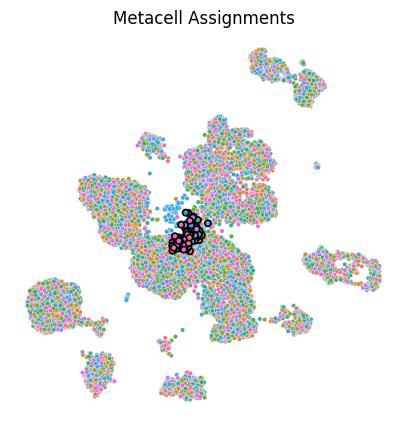

In [52]:
SEACells.plot.plot_2D(adata, colour_metacells=True)